# LangGraph 多代理人審核工作流

本例建立兩個分工不同的 Agent：

1. **Writer Agent**：根據主題產生內容。
2. **Reviewer Agent**：檢查內容品質，決定通過或退回修改。

只有 Reviewer 判定 `approved=True` 的內容才會進入 Publish Node；未通過的內容會帶著回饋退回 Writer。兩個 Agent 可以使用不同模型。

## 工作流程

```text
START → Writer Agent → Reviewer Agent
                           ├─ 通過 → Publish → END
                           ├─ 不通過 → Writer Agent（修改）
                           └─ 超過修改上限 → Failed → END
```

## 1. Import libraries

In [1]:
import os
from typing import Literal, TypedDict

from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

## 2. 建立兩個模型

請先設定系統環境變數 `OPENAI_API_KEY`。兩個 Agent 分別讀取：

- `WRITER_MODEL`：內容產生模型，預設為 `gpt-4o-mini`。
- `REVIEWER_MODEL`：品質審核模型，預設為 `gpt-4o`。

如果服務使用自訂 API endpoint，也可以設定 `OPENAI_BASE_URL`。

In [2]:
writer_model_name = os.getenv("WRITER_MODEL", "gpt-4o-mini")
reviewer_model_name = os.getenv("REVIEWER_MODEL", "gpt-4o")

common_options = {
    "api_key": os.environ["OPENAI_API_KEY"],
    "temperature": 0.0,
}

if os.getenv("OPENAI_BASE_URL"):
    common_options["base_url"] = os.environ["OPENAI_BASE_URL"]

writer_llm = ChatOpenAI(model=writer_model_name, **common_options)
reviewer_llm = ChatOpenAI(model=reviewer_model_name, **common_options)

print("Writer model:  ", writer_model_name)
print("Reviewer model:", reviewer_model_name)

Writer model:   gpt-4o-mini
Reviewer model: gpt-4o


## 3. 定義共享 State

State 是兩個 Agent 交換資料的地方：Writer 放入草稿，Reviewer 放入審核結果與修改意見。

In [3]:
class WorkflowState(TypedDict):
    topic: str
    requirements: str
    draft: str
    feedback: str
    approved: bool
    score: int
    revision_count: int
    status: str
    final_output: str

## 4. 定義 Reviewer 的結構化輸出

結構化輸出可以避免用字串比對 `OK`，讓 Router 直接使用明確的布林值。

In [4]:
class ReviewDecision(BaseModel):
    approved: bool = Field(description="內容是否符合所有要求，可以發布")
    score: int = Field(ge=1, le=5, description="內容品質分數，5 分最高")
    feedback: str = Field(description="通過理由，或具體、可執行的修改建議")


reviewer_with_schema = reviewer_llm.with_structured_output(ReviewDecision)

## 5. Writer Agent

第一次執行時 Writer 直接撰寫內容；被退回後，會同時收到上一版草稿與 Reviewer 的意見。

In [5]:
def writer_agent(state: WorkflowState):
    revision_number = state["revision_count"] + 1

    if state["draft"]:
        task = (
            f"請根據審核意見修改內容。\n\n"
            f"主題：{state['topic']}\n"
            f"要求：{state['requirements']}\n"
            f"上一版內容：\n{state['draft']}\n\n"
            f"審核意見：{state['feedback']}"
        )
    else:
        task = (
            f"請撰寫以下內容。\n\n"
            f"主題：{state['topic']}\n"
            f"要求：{state['requirements']}"
        )

    response = writer_llm.invoke(
        [
            SystemMessage("你是專業內容作者。請直接輸出完成的內容，不要描述寫作過程。"),
            HumanMessage(task),
        ]
    )

    print(f"Writer 完成第 {revision_number} 版")
    return {
        "draft": response.content,
        "revision_count": revision_number,
        "status": "waiting_for_review",
    }

## 6. Reviewer Agent

Reviewer 必須按照使用者的要求審核草稿。只有完全符合要求時才能將 `approved` 設為 `True`。

In [6]:
def reviewer_agent(state: WorkflowState):
    decision = reviewer_with_schema.invoke(
        [
            SystemMessage(
                "你是嚴格的內容審核員。請檢查正確性、完整性、清楚程度，"
                "以及是否符合所有要求。只有完全符合時才可通過。"
            ),
            HumanMessage(
                f"主題：{state['topic']}\n"
                f"要求：{state['requirements']}\n\n"
                f"待審內容：\n{state['draft']}"
            ),
        ]
    )

    result_text = "通過" if decision.approved else "退回修改"
    print(f"Reviewer：{result_text}（{decision.score}/5）")
    print(f"Feedback：{decision.feedback}")

    return {
        "approved": decision.approved,
        "score": decision.score,
        "feedback": decision.feedback,
    }

## 7. Router 與終點 Nodes

Router 根據 Reviewer 的決定選擇下一條 Edge。`MAX_REVISIONS` 可以防止 Agent 永久互相退件。

In [7]:
MAX_REVISIONS = 3


def review_router(state: WorkflowState) -> Literal["publish", "revise", "failed"]:
    if state["approved"]:
        return "publish"

    if state["revision_count"] >= MAX_REVISIONS:
        return "failed"

    return "revise"


def publish_content(state: WorkflowState):
    print("內容已通過審核，可以發布。")
    return {
        "status": "approved",
        "final_output": state["draft"],
    }


def mark_as_failed(state: WorkflowState):
    print("內容達到修改次數上限，未獲准發布。")
    return {
        "status": "rejected",
        "final_output": "",
    }

## 8. 建立 LangGraph

In [8]:
workflow = StateGraph(WorkflowState)

workflow.add_node("writer", writer_agent)
workflow.add_node("reviewer", reviewer_agent)
workflow.add_node("publish", publish_content)
workflow.add_node("failed", mark_as_failed)

workflow.add_edge(START, "writer")
workflow.add_edge("writer", "reviewer")
workflow.add_conditional_edges(
    "reviewer",
    review_router,
    {
        "publish": "publish",
        "revise": "writer",
        "failed": "failed",
    },
)
workflow.add_edge("publish", END)
workflow.add_edge("failed", END)

graph = workflow.compile()

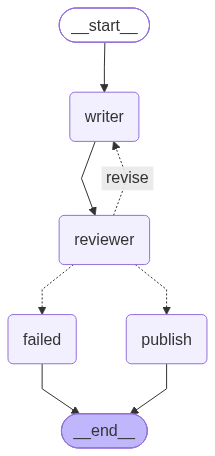

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 9. 執行多代理人工作流

以下任務要求 Writer 撰寫一段教學內容。Reviewer 會檢查是否符合字數、受眾與內容要求。

In [10]:
initial_state: WorkflowState = {
    "topic": "什麼是 LangGraph State",
    "requirements": (
        "以繁體中文撰寫 150 至 250 字的初學者教學；"
        "必須包含 State 的用途、一個簡短例子，以及一項注意事項。"
    ),
    "draft": "",
    "feedback": "",
    "approved": False,
    "score": 0,
    "revision_count": 0,
    "status": "not_started",
    "final_output": "",
}

result = graph.invoke(
    initial_state,
    config={"recursion_limit": 10},
)

Writer 完成第 1 版
Reviewer：通過（5/5）
Feedback：內容完整且清晰地介紹了 LangGraph State 的用途，提供了簡單易懂的例子，並指出了使用時需要注意的事項。符合所有要求，適合初學者理解。
內容已通過審核，可以發布。


## 10. 查看結果

`final_output` 只有在 Reviewer 通過後才會有內容。若達到修改上限仍未通過，狀態會是 `rejected`。

In [11]:
print("Status:       ", result["status"])
print("Approved:     ", result["approved"])
print("Score:        ", result["score"])
print("Revisions:    ", result["revision_count"])
print("Last feedback:", result["feedback"])

if result["status"] == "approved":
    print("\nPublished content:\n")
    print(result["final_output"])
else:
    print("\n內容未通過，因此沒有發布。")

Status:        approved
Approved:      True
Score:         5
Revisions:     1
Last feedback: 內容完整且清晰地介紹了 LangGraph State 的用途，提供了簡單易懂的例子，並指出了使用時需要注意的事項。符合所有要求，適合初學者理解。

Published content:

LangGraph State 是一種用於管理和追蹤應用程式狀態的工具，特別是在開發互動式應用時非常有用。State 允許開發者儲存和更新用戶的資料、應用程式的設定或其他需要持續追蹤的資訊。透過有效的狀態管理，開發者可以確保應用程式在不同情境下的行為一致性，並提升用戶體驗。

舉個簡單的例子，假設你正在開發一個待辦事項應用。你可以使用 State 來儲存用戶的待辦事項列表。當用戶新增一項任務時，應用程式會更新 State，並自動在介面上顯示最新的任務列表。這樣，用戶每次打開應用時，都能看到他們的最新待辦事項。

不過，使用 State 時需要注意的是，過度頻繁地更新 State 可能會導致性能問題，特別是在大型應用中。因此，建議開發者在設計時謹慎考量何時以及如何更新 State，以保持應用的流暢性和效率。


## 重點整理

| 概念 | 本例的實作 |
|---|---|
| 多代理人 | Writer 與 Reviewer 各自負責不同任務 |
| 不同模型 | `WRITER_MODEL` 與 `REVIEWER_MODEL` 分開設定 |
| 共享資料 | 透過 `WorkflowState` 傳遞草稿、回饋與審核結果 |
| 條件路由 | `review_router` 決定發布、修改或拒絕 |
| Feedback loop | Reviewer 不通過時回到 Writer |
| 放行控制 | 只有 `approved=True` 才能進入 Publish Node |
| 防止無限循環 | 最多修改 `MAX_REVISIONS` 次 |

> 這個範例沒有加入 memory，因為同一次 `graph.invoke()` 的 State 已足以保存整個審核循環。若需要跨多次呼叫延續任務，才需要加入 checkpointer。